# Preprocessing Lung Sounds

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
import random
random.seed(42)

import pandas as pd
from matplotlib import pyplot as plt

from modules.dataset import ICBHIDataset, FraiwanDataset, CombinedLungSoundDataset, LungSoundDataset
from modules.transforms import *

# NOTE: Some classes have very few samples, so we will focus on a subset of classes for the analysis.
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    # "Bronchitis",
    "COPD",
    "Healthy",
    # "Heart Failure",
    # "LRTI",
    "Lung Fibrosis",
    # "Pleural Effusion",
    "Pneumonia",
    "URTI",
]

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), "data")
if not os.path.exists(data_path):
    print(f"Data directory not found at {data_path}. Please ensure the data is downloaded and placed in the correct location.")

In [3]:
TARGET_SR = 44100   # Hz
WINDOW_LENGTH = 6   # seconds

# Example of a transformation pipeline that can be applied to the audio data
data_transforms = Compose([
    Resample(target_sr=TARGET_SR),
    Window(window_length=WINDOW_LENGTH),
    Normalize(),
    Spectrogram(n_fft=2048, hop_length=512),
])

In [4]:
def plot_label_distribution(dataset: LungSoundDataset):
    """
    Plot the distribution of labels in the dataset.
    Args:
        dataset (LungSoundDataset): The dataset containing label information.
    """
    data = dataset.data
    label_counts = data["Diagnosis"].value_counts()
    display(label_counts)
    label_counts.plot(kind="bar")
    plt.title("Label Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

ICBHI Dataset size: 2972 samples


Diagnosis
COPD              2597
Pneumonia          111
Healthy            105
URTI                69
Bronchiectasis      48
Bronchiolitis       39
Asthma               3
Name: count, dtype: int64

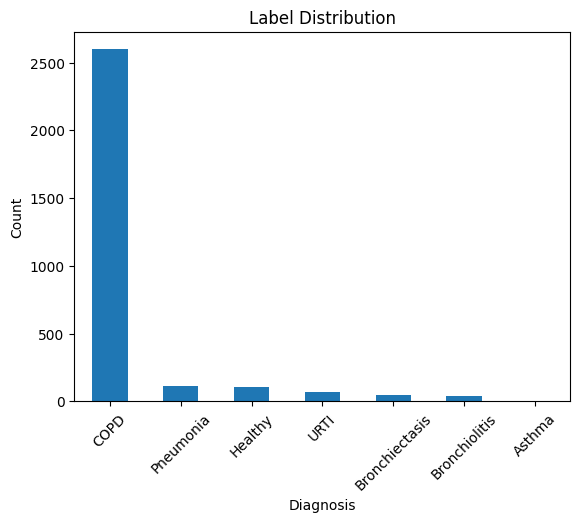

In [5]:
icbhi_dataset = ICBHIDataset(data_path, "all", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"ICBHI Dataset size: {len(icbhi_dataset)} samples")
plot_label_distribution(icbhi_dataset)

Fraiwan Dataset size: 629 samples


Diagnosis
Healthy          272
Asthma           228
COPD              63
Pneumonia         42
Lung Fibrosis     24
Name: count, dtype: int64

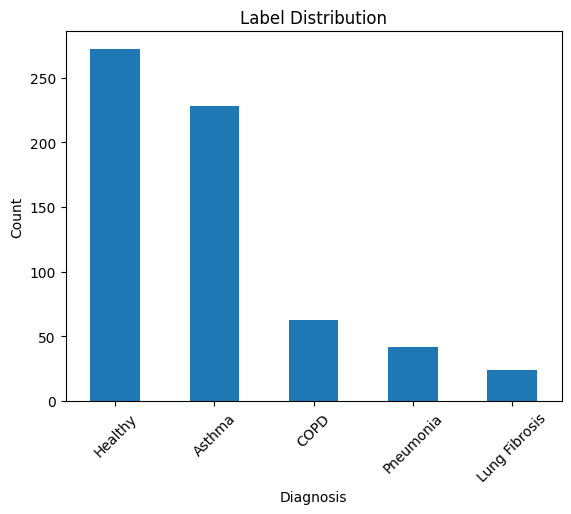

In [6]:
fraiwan_dataset = FraiwanDataset(data_path, "all", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"Fraiwan Dataset size: {len(fraiwan_dataset)} samples")
plot_label_distribution(fraiwan_dataset)

Dataset size: 3601 samples


Diagnosis
COPD              2660
Healthy            377
Asthma             231
Pneumonia          153
URTI                69
Bronchiectasis      48
Bronchiolitis       39
Lung Fibrosis       24
Name: count, dtype: int64

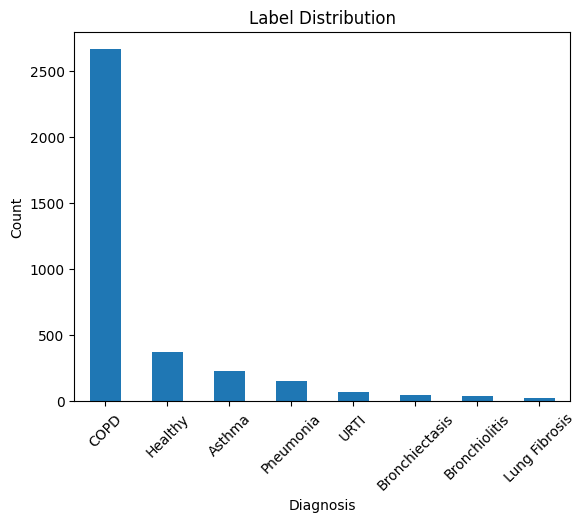

In [7]:
combined_dataset = CombinedLungSoundDataset(data_path, "all", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"Dataset size: {len(combined_dataset)} samples")
plot_label_distribution(combined_dataset)

Sample 0:
  File name: 101_1b1_Al_sc_Meditron.wav
  Label: 7 (URTI)
  Sample rate: 44100
  Audio shape: (264600,)


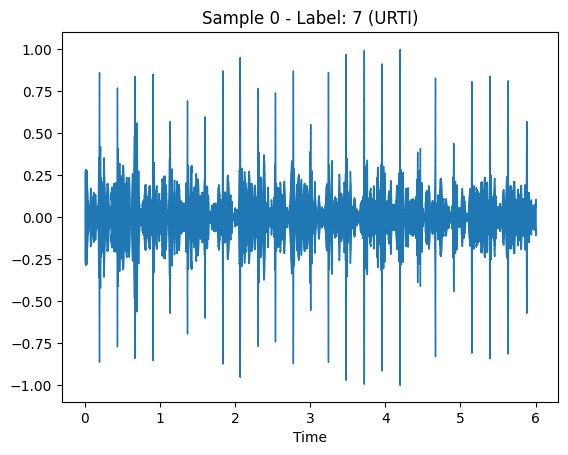

  Features shape: (1025, 517)
  Features dimensions: 2
  Features dtype: float32


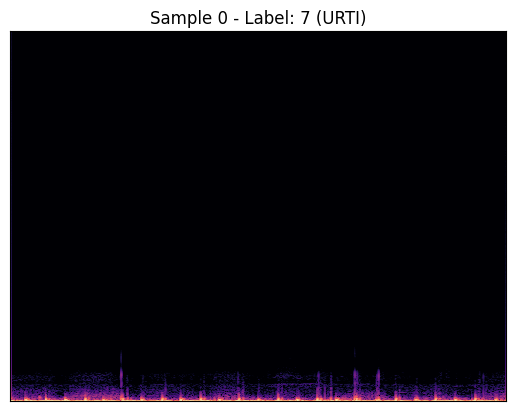

In [8]:
combined_dataset.unit_test(idx=0)

In [9]:
def get_samples_by_label(dataset: LungSoundDataset) -> dict:
    """
    Get one sample for each label in the dataset.
    Args:
        dataset (LungSoundDataset): The dataset to sample from.
    Returns:
        dict: A dictionary mapping each label to a random sample index.
    """
    data = dataset.data
    samples = {}
    for label in sorted(data["Diagnosis"].unique()):
        label_samples = data[data["Diagnosis"] == label]
        random_idx = random.choice(label_samples.index.tolist())
        samples[label] = random_idx
    return samples

def plot_features_by_label(data_path: str, dataset_class: type[LungSoundDataset], samples: dict = None) -> None:
    if samples is None:
        dataset = dataset_class(data_path, "all", classes=SELECTED_CLASSES, transform=Window(window_length=WINDOW_LENGTH))
        samples = get_samples_by_label(dataset)
        print("Sampled records:")
        for label, sample in samples.items():
            print(f"Class: {label}, idx: {sample}")

    feature_extractors = [
        Spectrogram(),
        MelSpectrogram(n_mels=128),
        MFCC(n_mfcc=20),
        MFCCDelta(n_mfcc=20),
        Chroma(),
        SpectralContrast(n_bands=4, fmin=50),
        CQT(n_bins=48, fmin=30, bins_per_octave=12),
        Phase(),
    ]

    for extractor in feature_extractors:
        num_classes = len(samples)
        num_rows = (num_classes + 3) // 4
        num_cols = min(num_classes, 4)
        figure, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
        axes = axes.flatten()

        extractor_name = extractor.__class__.__name__

        if isinstance(extractor, Spectrogram):
            params = {"x_axis": "time", "y_axis": "log"}
            cbar_format = "%+2.0f dB"
        elif isinstance(extractor, MelSpectrogram):
            params = {"x_axis": "time", "y_axis": "mel"}
            cbar_format = "%+2.0f dB"
        elif isinstance(extractor, MFCC) or isinstance(extractor, MFCCDelta):
            params = {"x_axis": "time", "y_axis": None}
            cbar_format = "%+2.0f"
        elif isinstance(extractor, Chroma):
            params = {"x_axis": "time", "y_axis": "chroma"}
            cbar_format = "%+2.0f"
        elif isinstance(extractor, SpectralContrast):
            params = {"x_axis": "time", "y_axis": None}
            cbar_format = "%+2.0f dB"
        elif isinstance(extractor, CQT):
            params = {"x_axis": "time", "y_axis": "cqt_note"}
            cbar_format = "%+2.0f"
        elif isinstance(extractor, Phase):
            params = {"x_axis": "time", "y_axis": "linear"}
            cbar_format = "%+2.0f rad"
        else:
            params = {"x_axis": "time", "y_axis": "linear"}
            cbar_format = "%+2.0f"

        transform = Compose([
            Resample(target_sr=TARGET_SR),
            Window(window_length=WINDOW_LENGTH),
            Normalize(),
            extractor,
        ])
        dataset = dataset_class(data_path, "all", classes=SELECTED_CLASSES, transform=transform)

        for i, (label, idx) in enumerate(samples.items()):
            ax = axes[i]
            sample, _ = dataset[idx]
            img = sample.plot_features(title=f"{label}", ax=ax, **params)
            plt.colorbar(img, ax=ax, format=cbar_format)
        figure.suptitle(f"{extractor_name}")
        plt.tight_layout()
        plt.show()

Sampled records:
Class: Asthma, idx: 3422
Class: Bronchiectasis, idx: 244
Class: Bronchiolitis, idx: 967
Class: COPD, idx: 1297
Class: Healthy, idx: 3061
Class: Lung Fibrosis, idx: 3069
Class: Pneumonia, idx: 678
Class: URTI, idx: 389


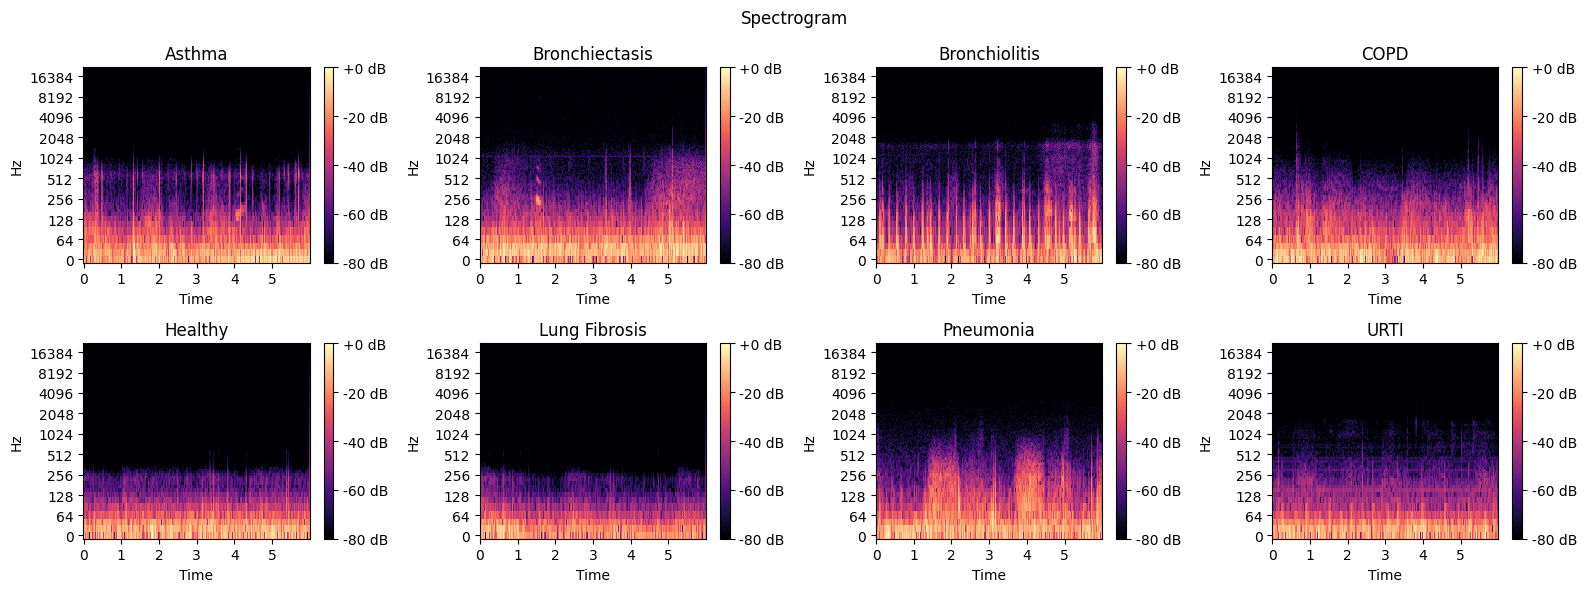

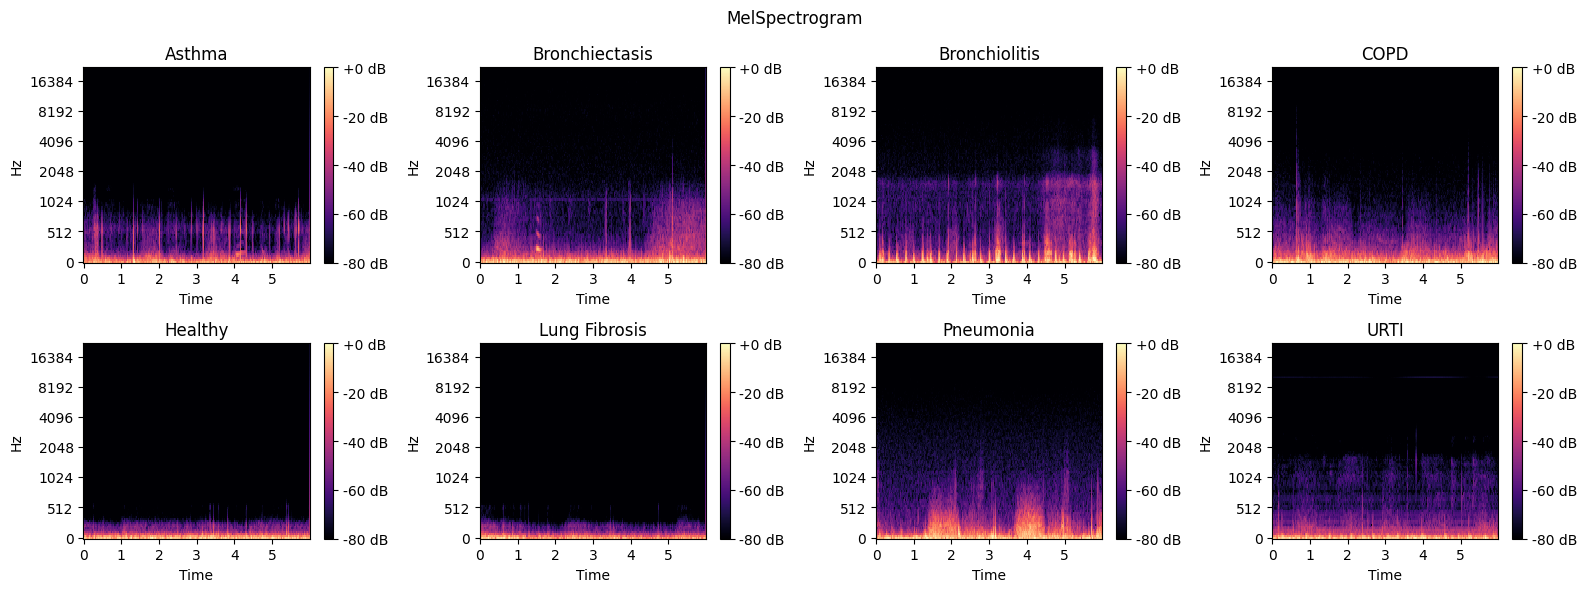

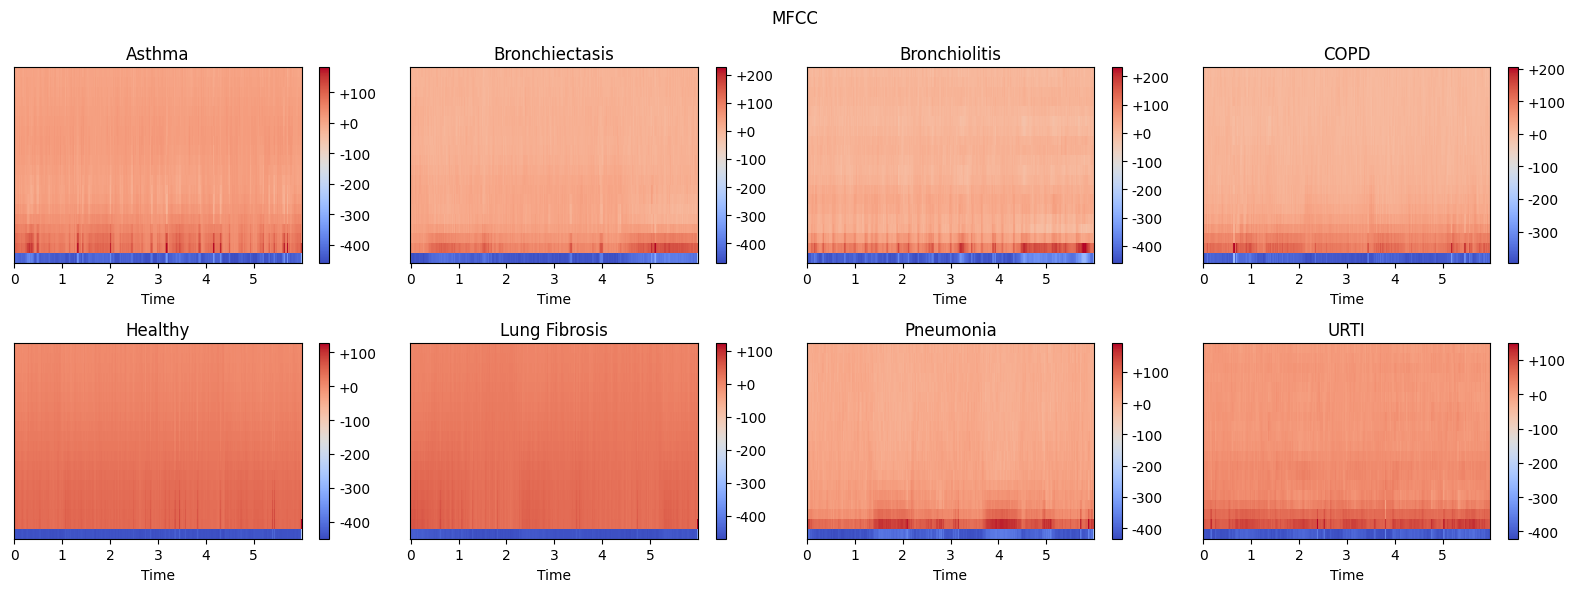

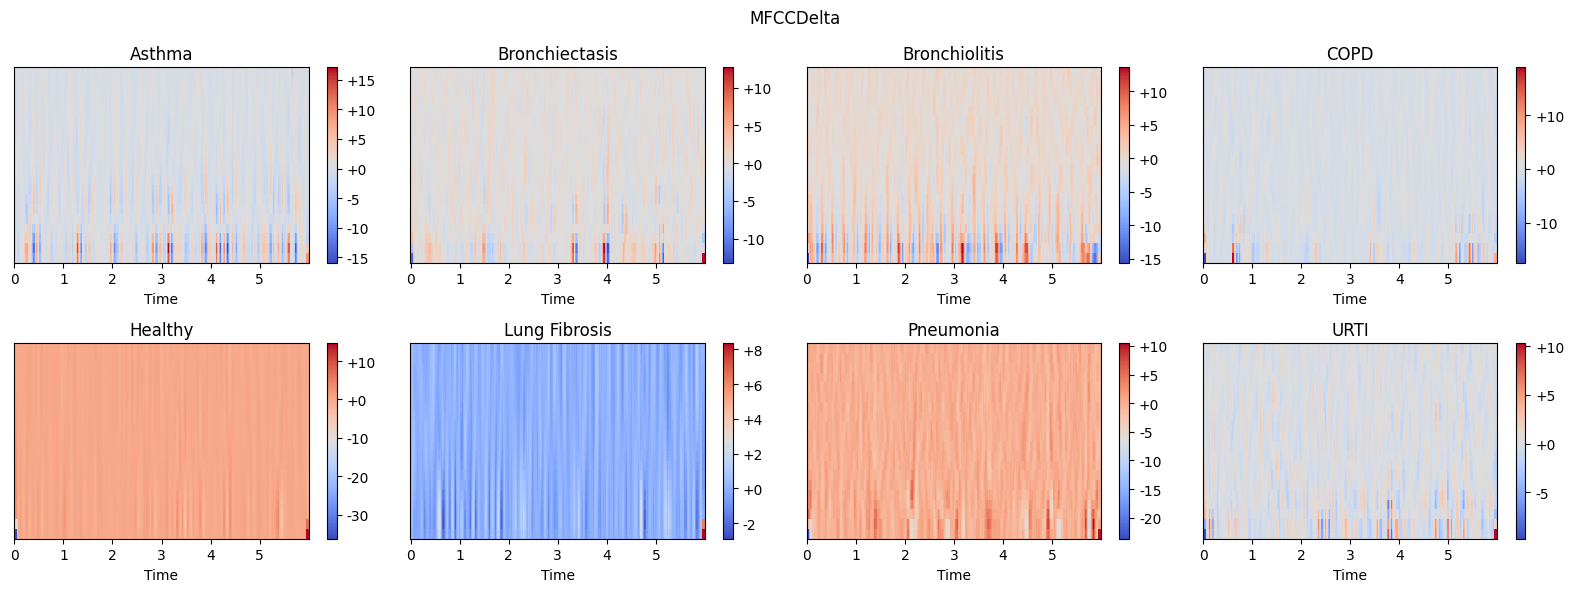

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


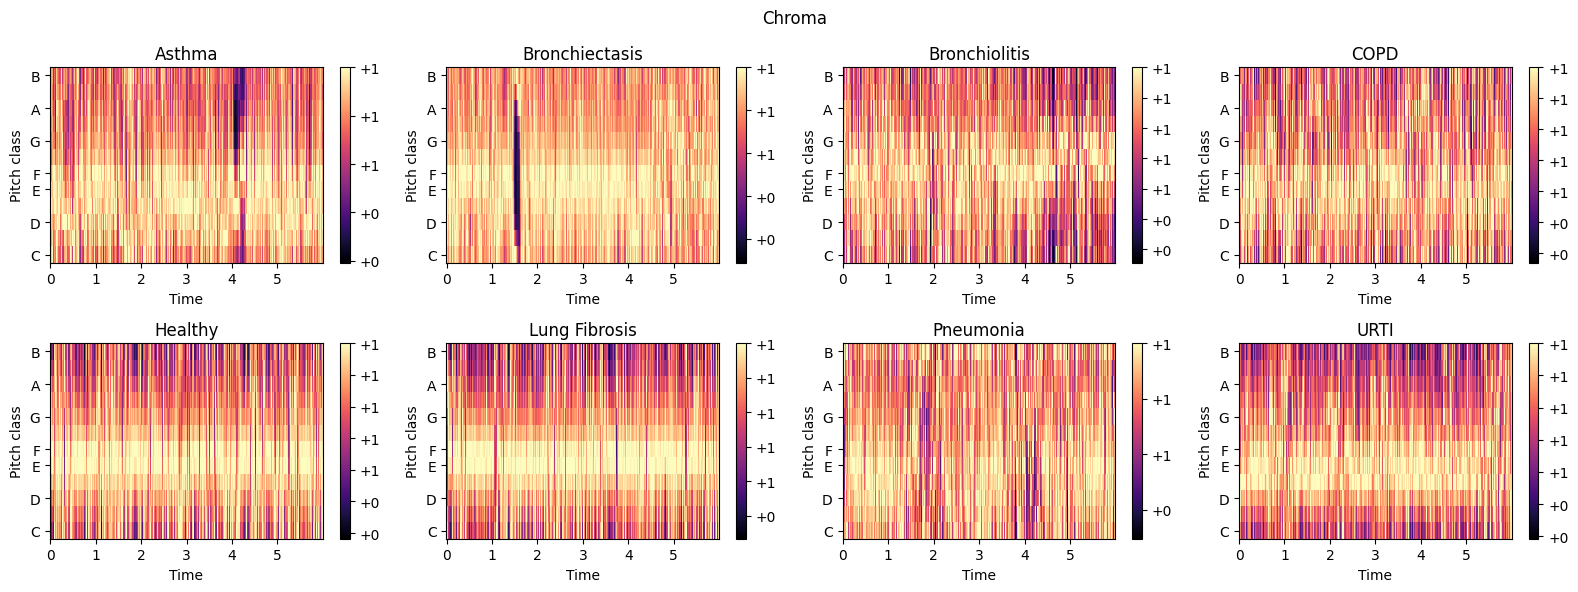

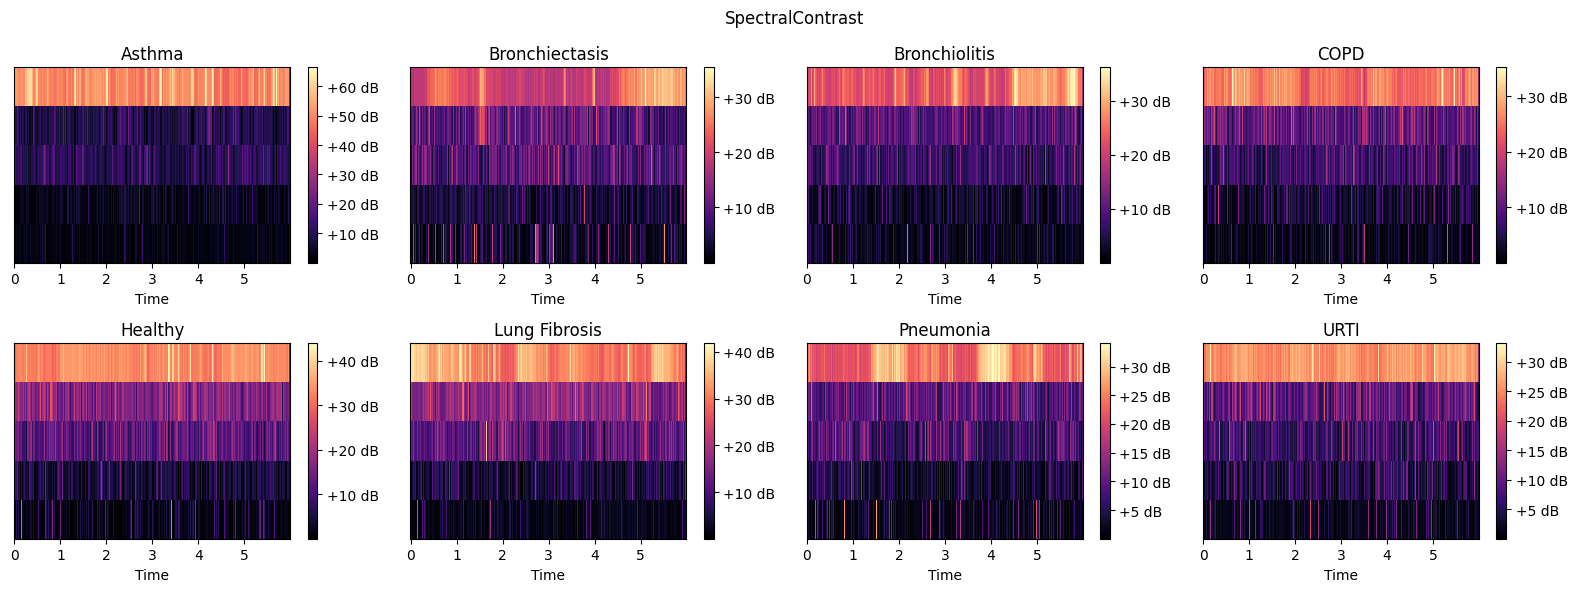

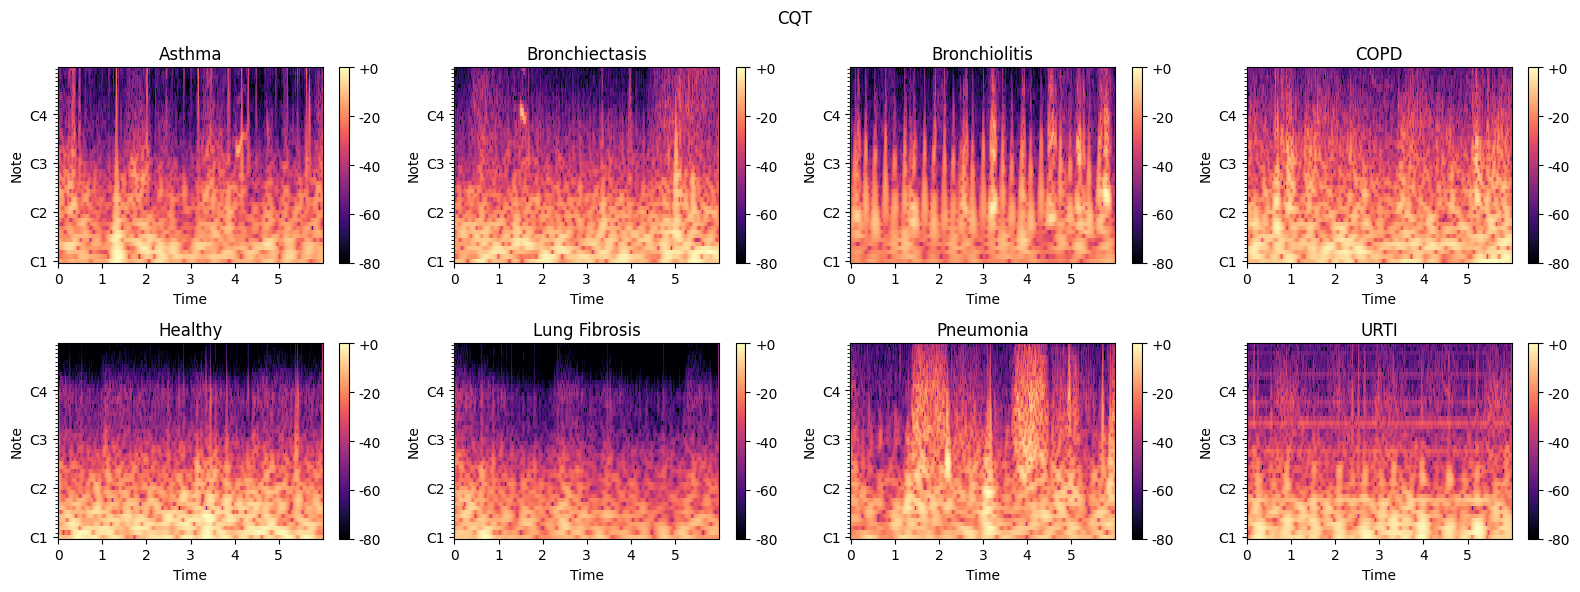

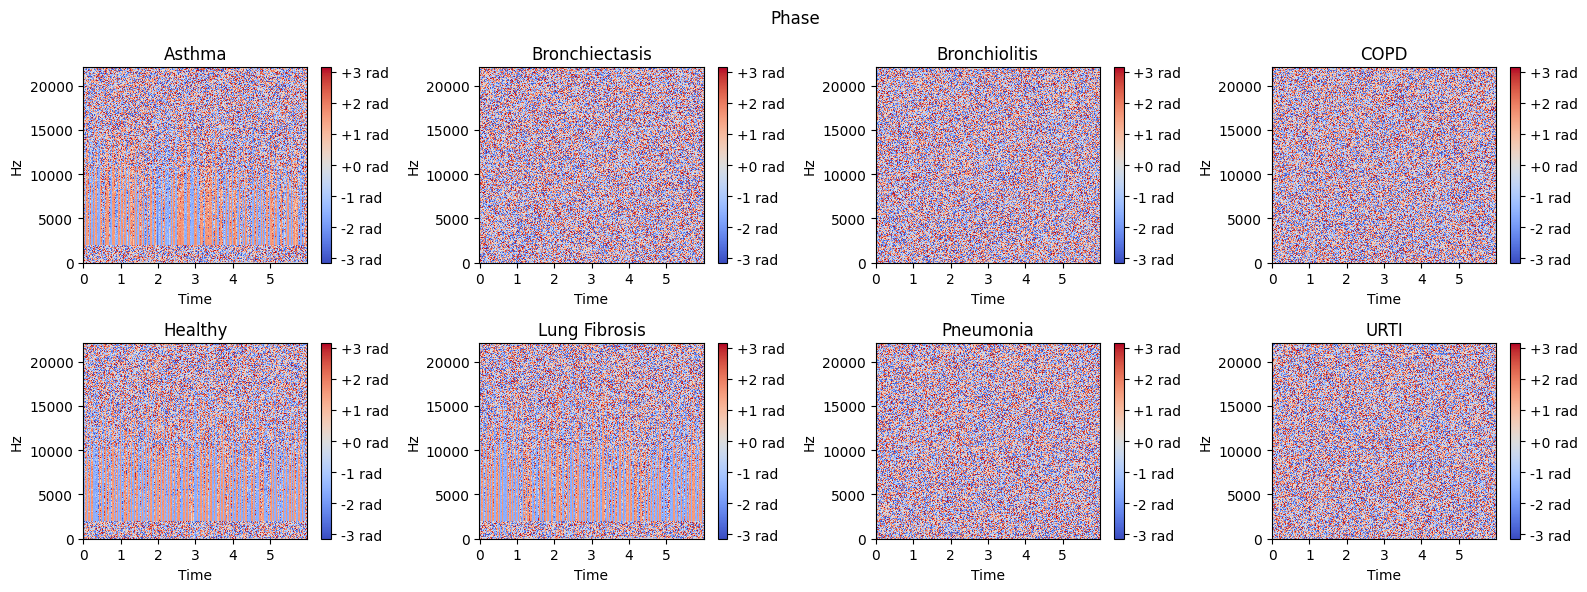

In [10]:
plot_features_by_label(data_path, CombinedLungSoundDataset)